In [1]:
import micropip
await micropip.install('seaborn')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

%matplotlib inline

df = pd.read_csv("loan_data.csv")
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [3]:
print("Колонки датасету:")
print(df.columns)

print("\nРозмір датасету (рядки, колонки):")
print(df.shape)


Колонки датасету:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

Розмір датасету (рядки, колонки):
(381, 13)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 26.9+ KB


In [5]:
df.isnull().sum()

Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
df_clean = df.copy()

num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_clean.select_dtypes(include=['object']).columns.drop('Loan_Status')

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean['Loan_Status'] = df_clean['Loan_Status'].map({'N': 0, 'Y': 1})

print(df_clean.isnull().sum())


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [7]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=cat_cols,
    drop_first=True
)
df_encoded.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Loan_ID_LP001005,Loan_ID_LP001006,Loan_ID_LP001008,Loan_ID_LP001013,...,Loan_ID_LP002990,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,4583,1508.0,128.0,360.0,1.0,0,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1,3000,0.0,66.0,360.0,1.0,1,True,False,False,False,...,False,True,True,False,False,False,False,True,False,True
2,2583,2358.0,120.0,360.0,1.0,1,False,True,False,False,...,False,True,True,False,False,False,True,False,False,True
3,6000,0.0,141.0,360.0,1.0,1,False,False,True,False,...,False,True,False,False,False,False,False,False,False,True
4,2333,1516.0,95.0,360.0,1.0,1,False,False,False,True,...,False,True,True,False,False,False,True,False,False,True


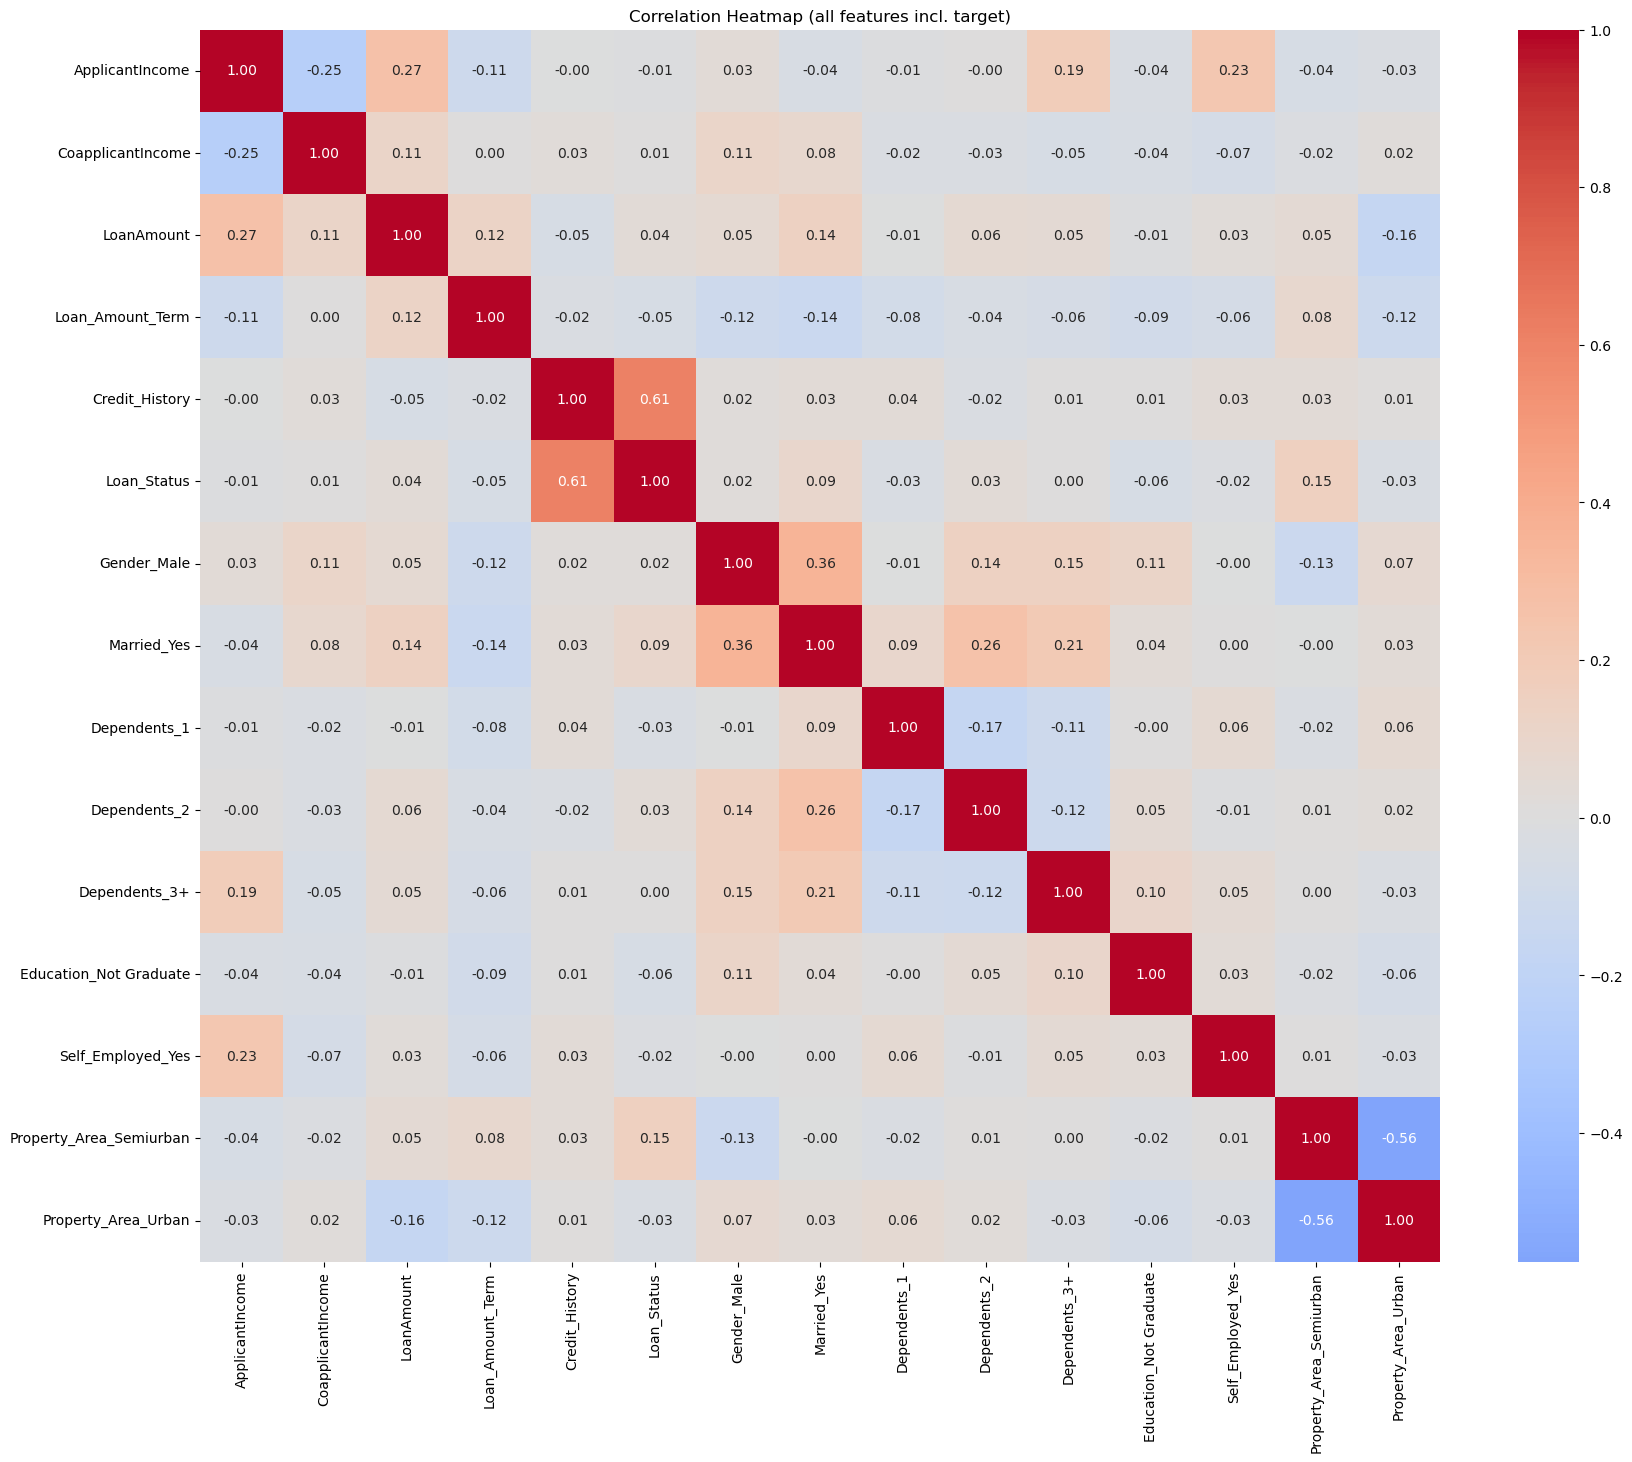

In [8]:
df_for_corr = df_clean.drop(columns=['Loan_ID'])
cat_cols_corr = df_for_corr.select_dtypes(include=['object']).columns

df_corr_encoded = pd.get_dummies(
    df_for_corr,
    columns=cat_cols_corr,
    drop_first=True
)

plt.figure(figsize=(20, 16))
sns.heatmap(
    df_corr_encoded.corr(),
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Heatmap (all features incl. target)")
plt.show()



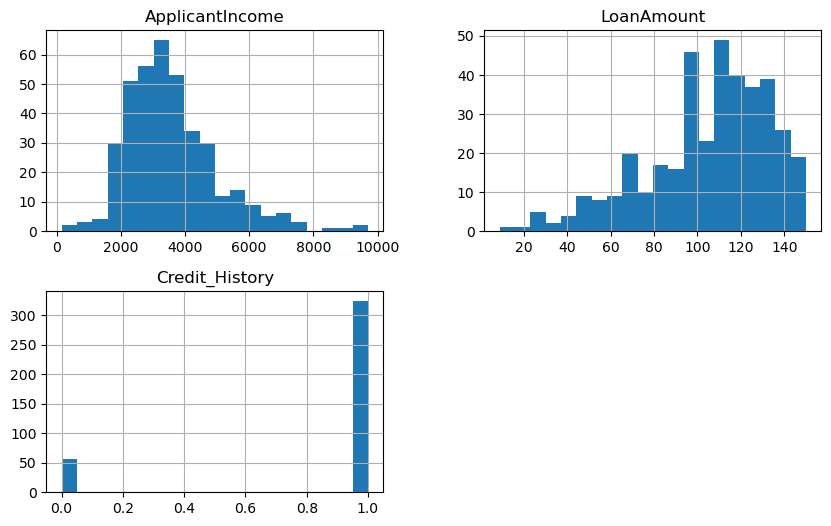

In [9]:
df_clean[['ApplicantIncome', 'LoanAmount', 'Credit_History']].hist(
    figsize=(10, 6),
    bins=20
)
plt.show()


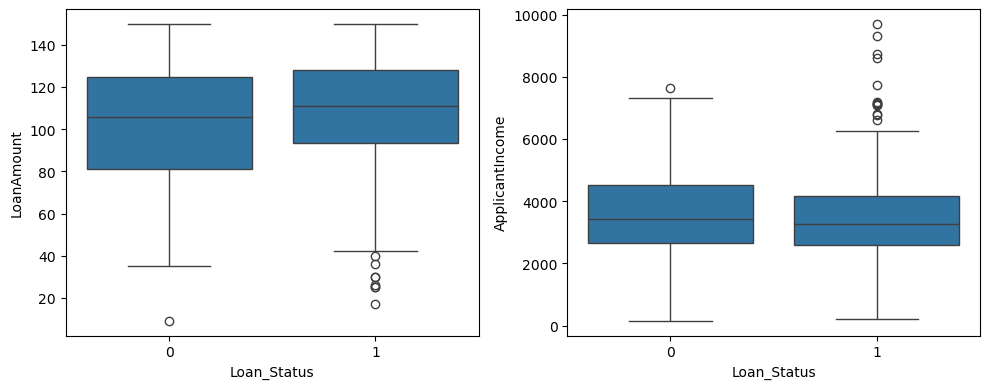

In [10]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df_clean)
plt.subplot(1, 2, 2)
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df_clean)
plt.tight_layout()
plt.show()


In [11]:
X = df_clean.drop(columns=['Loan_Status', 'Loan_ID'])
y = df_clean['Loan_Status']

cat_cols_ml = X.select_dtypes(include=['object']).columns

X_encoded = pd.get_dummies(
    X,
    columns=cat_cols_ml,
    drop_first=True
)


X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)


(285, 14) (96, 14)


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_encoded.dtypes.value_counts())
print(y.value_counts())


bool       9
float64    4
int64      1
Name: count, dtype: int64
Loan_Status
1    271
0    110
Name: count, dtype: int64


In [13]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))



[[11 17]
 [ 1 67]]
              precision    recall  f1-score   support

           0       0.92      0.39      0.55        28
           1       0.80      0.99      0.88        68

    accuracy                           0.81        96
   macro avg       0.86      0.69      0.72        96
weighted avg       0.83      0.81      0.78        96



In [14]:
error_rate = []

for i in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))


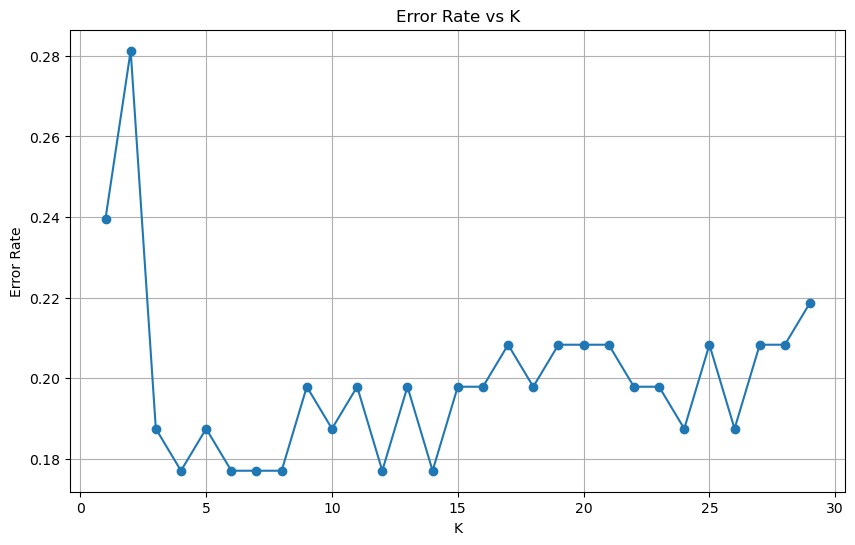

In [15]:
plt.figure(figsize=(10,6))
plt.plot(range(1,30), error_rate, marker='o')
plt.title('Error Rate vs K')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.grid()
plt.show()


In [16]:
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))


              precision    recall  f1-score   support

           0       0.79      0.54      0.64        28
           1       0.83      0.94      0.88        68

    accuracy                           0.82        96
   macro avg       0.81      0.74      0.76        96
weighted avg       0.82      0.82      0.81        96

[[15 13]
 [ 4 64]]


In [17]:
dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree classification report:")
print(classification_report(y_test, y_pred_dt))

print("Decision Tree confusion matrix:")
print(confusion_matrix(y_test, y_pred_dt))


Decision Tree classification report:
              precision    recall  f1-score   support

           0       0.73      0.57      0.64        28
           1       0.84      0.91      0.87        68

    accuracy                           0.81        96
   macro avg       0.78      0.74      0.76        96
weighted avg       0.81      0.81      0.81        96

Decision Tree confusion matrix:
[[16 12]
 [ 6 62]]


In [18]:
svm = SVC(kernel='rbf', class_weight='balanced')

svm_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1]
}

svm_grid = GridSearchCV(
    svm,
    svm_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)

best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)

print("Best SVM params:", svm_grid.best_params_)
print("SVM classification report:")
print(classification_report(y_test, y_pred_svm))
print("SVM confusion matrix:")
print(confusion_matrix(y_test, y_pred_svm))


Best SVM params: {'C': 1, 'gamma': 0.01}
SVM classification report:
              precision    recall  f1-score   support

           0       0.93      0.50      0.65        28
           1       0.83      0.99      0.90        68

    accuracy                           0.84        96
   macro avg       0.88      0.74      0.78        96
weighted avg       0.86      0.84      0.83        96

SVM confusion matrix:
[[14 14]
 [ 1 67]]


In [19]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.54      0.70        28
           1       0.84      1.00      0.91        68

    accuracy                           0.86        96
   macro avg       0.92      0.77      0.81        96
weighted avg       0.89      0.86      0.85        96



In [20]:
ada = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.3,
    random_state=42
)

ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print(classification_report(y_test, y_pred_ada))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67        28
           1       0.83      1.00      0.91        68

    accuracy                           0.85        96
   macro avg       0.91      0.75      0.79        96
weighted avg       0.88      0.85      0.84        96



In [21]:
results_data = []

models_list = [
    ("kNN", y_pred_knn),
    ("Decision Tree", y_pred_dt),
    ("SVM", y_pred_svm),
    ("Random Forest", y_pred_rf),
    ("AdaBoost", y_pred_ada)
]

for name, preds in models_list:
    report = classification_report(y_test, preds, output_dict=True)
    results_data.append({
        "Model": name,
        "Accuracy": report['accuracy'],
        "F1-score (Class 0)": report['0']['f1-score'], 
        "F1-score (Class 1)": report['1']['f1-score'],  
        "Macro F1-avg": report['macro avg']['f1-score'] 
    })
results_df = pd.DataFrame(results_data).set_index("Model")
results_df = results_df.sort_values(by='Macro F1-avg', ascending=False)

print(results_df)

               Accuracy  F1-score (Class 0)  F1-score (Class 1)  Macro F1-avg
Model                                                                        
Random Forest  0.864583            0.697674            0.912752      0.805213
AdaBoost       0.854167            0.666667            0.906667      0.786667
SVM            0.843750            0.651163            0.899329      0.775246
kNN            0.822917            0.638298            0.882759      0.760528
Decision Tree  0.812500            0.640000            0.873239      0.756620
